In [19]:
from google.colab import drive
import os

drive.mount('/content/drive', force_remount=True)

drive_path = "/content/drive/MyDrive/PROJECT_FSD50K"
local_path = "/content/fsd50k_local"

# Only extract the audio archives if they haven't been extracted already
dev_audio_dir = os.path.join(local_path, "FSD50K.dev_audio")

if os.path.exists(dev_audio_dir) and len(os.listdir(dev_audio_dir)) > 100:
    print(f"Dataset already extracted at {local_path}")
else:
    print("Extracting dataset archives")
    !unzip -q {drive_path}/FSD50K.metadata.zip -d {local_path}
    !unzip -q {drive_path}/FSD50K.ground_truth.zip -d {local_path}
    !7z x {drive_path}/FSD50K.eval_audio.zip -o{local_path} -y > /dev/null
    !7z x {drive_path}/FSD50K.dev_audio.zip -o{local_path} -y > /dev/null
    print("Extraction complete.")

Mounted at /content/drive
Extracting dataset archives
replace /content/fsd50k_local/FSD50K.metadata/eval_clips_info_FSD50K.json? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace /content/fsd50k_local/FSD50K.metadata/pp_pnp_ratings_FSD50K.json? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace /content/fsd50k_local/FSD50K.metadata/class_info_FSD50K.json? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace /content/fsd50k_local/FSD50K.metadata/dev_clips_info_FSD50K.json? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace /content/fsd50k_local/FSD50K.metadata/collection/vocabulary_collection_eval.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
replace /content/fsd50k_local/FSD50K.ground_truth/vocabulary.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
Extraction complete.


# **Robustness Evaluation under Noisy Conditions**

## **Purpose**

This notebook measures how the CNN (ResNet-18) and AST models degrade when the input audio is corrupted by additive noise. Both models were trained with SpecAugment as part of their standard regularization pipeline in notebooks `04_cnn` and `05_ast`. This notebook does not retrain anything; it loads the saved checkpoints and evaluates them on the FSD50K evaluation set under controlled noise conditions.

Two types of noise are used:

- **Gaussian (white) noise**: the canonical benchmark in audio robustness literature, with energy uniformly distributed across all frequencies.
- **Pink noise**: a more realistic proxy for environmental noise (traffic, crowd murmur, wind), with energy decaying as 1/f.

Five levels of signal-to-noise ratio (SNR) are evaluated for each noise type: clean reference, 20 dB (barely perceptible noise), 10 dB (moderate), 5 dB (loud), and 0 dB (signal and noise at equal power).

In [20]:
import os
import json
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchaudio
import torchaudio.transforms as T
from torchvision.models import resnet18
from transformers import ASTForAudioClassification, ASTFeatureExtractor
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics import f1_score, average_precision_score
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from collections import Counter

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

torch.manual_seed(42)
np.random.seed(42)

Device: cuda


## **Loading Vocabulary and Test Set**

Both models share the same 100-class vocabulary defined in `03_label_correlation_analysis`. The evaluation uses only the FSD50K eval split (the official test set), never seen during training.

In [21]:
# Load vocabulary configuration
with open("/content/drive/MyDrive/PROJECT_FSD50K/label_config.json") as f:
    cfg = json.load(f)

DROP_LABELS = set(cfg["drop_labels"])
VOCAB_SIZE  = cfg["vocabulary_size"]

# Load eval ground truth
EVAL_CSV   = "/content/fsd50k_local/FSD50K.ground_truth/eval.csv"
EVAL_AUDIO = "/content/fsd50k_local/FSD50K.eval_audio"

eval_df = pd.read_csv(EVAL_CSV)
eval_df["path"]       = eval_df["fname"].astype(str).apply(lambda x: os.path.join(EVAL_AUDIO, f"{x}.wav"))
eval_df["label_list"] = eval_df["labels"].astype(str).str.split(",")

# Rebuild top_labels from dev split to keep the exact same vocabulary
DEV_CSV = "/content/fsd50k_local/FSD50K.ground_truth/dev.csv"
dev_df  = pd.read_csv(DEV_CSV)
dev_df["label_list"] = dev_df["labels"].astype(str).str.split(",")

all_labels   = [l for ls in dev_df["label_list"] for l in ls]
label_counts = Counter(all_labels)
top_labels   = [l for l, _ in label_counts.most_common() if l not in DROP_LABELS][:VOCAB_SIZE]

# Filter and binarize
eval_df["label_filt"] = eval_df["label_list"].apply(lambda lst: [l for l in lst if l in top_labels])
eval_df = eval_df[eval_df["label_filt"].apply(len) > 0].reset_index(drop=True)

mlb = MultiLabelBinarizer(classes=top_labels)
mlb.fit([top_labels])
NUM_CLASSES = len(top_labels)

print(f"Eval samples: {len(eval_df)}  |  Classes: {NUM_CLASSES}")

Eval samples: 9878  |  Classes: 100


## **Noise Generation Functions**

Noise is injected at the waveform level (before any feature extraction), mimicking real-world acoustic contamination. The SNR determines the noise power relative to the signal:

$$P_{\text{noise}} = \frac{P_{\text{signal}}}{10^{\text{SNR}/10}}$$

Gaussian noise has flat spectral density. Pink noise is generated by filtering Gaussian noise in the frequency domain with a 1/√f amplitude response, producing the characteristic 1/f² power decay. The random seed is fixed per SNR level to ensure reproducibility across runs.

In [22]:
def add_gaussian_noise(wav, snr_db):
    """Add white Gaussian noise at a specified SNR (dB)."""
    sig_p   = np.mean(wav**2) + 1e-10
    noise_p = sig_p / (10 ** (snr_db / 10))
    noise   = np.random.randn(len(wav)).astype(np.float32) * np.sqrt(noise_p)
    return wav + noise


def add_pink_noise(wav, snr_db, sr=16000):
    """Add pink (1/f) noise at a specified SNR (dB) using FFT shaping."""
    length = len(wav)
    white  = np.random.randn(length).astype(np.float32)
    # 1/sqrt(f) amplitude shaping in the frequency domain
    freqs       = np.fft.rfftfreq(length, d=1/sr)
    freqs[0]    = 1.0
    spectrum    = np.fft.rfft(white) / np.sqrt(freqs)
    pink        = np.fft.irfft(spectrum, length).astype(np.float32)
    pink        = pink / (np.std(pink) + 1e-10)
    # Scale to desired SNR
    sig_p   = np.mean(wav**2) + 1e-10
    noise_p = sig_p / (10 ** (snr_db / 10))
    return wav + pink * np.sqrt(noise_p)

## **Dataset Classes**

The CNN uses Mel-spectrograms; the AST uses its own feature extractor. Both read the same waveform and receive the same injected noise. Two dataset classes are defined (one per model) with shared `noise_type` and `snr_db` arguments that select the type and intensity of the added noise.

In [23]:
SR        = 16000
DURATION  = 10
N_SAMPLES = SR * DURATION


def load_waveform(path):
    """Load, mono-mix, resample to 16 kHz, and pad/truncate to 10 s."""
    wav, sr = torchaudio.load(path)
    if wav.shape[0] > 1:
        wav = wav.mean(dim=0, keepdim=True)
    if sr != SR:
        wav = torchaudio.functional.resample(wav, sr, SR)
    wav = wav.squeeze(0).numpy().astype(np.float32)
    if wav.shape[0] > N_SAMPLES:
        wav = wav[:N_SAMPLES]
    else:
        wav = np.pad(wav, (0, N_SAMPLES - wav.shape[0]))
    return wav


def apply_noise(wav, noise_type, snr_db):
    """Dispatch to the correct noise function; return unchanged for 'clean'."""
    if noise_type == "clean" or snr_db is None:
        return wav
    if noise_type == "gaussian":
        return add_gaussian_noise(wav, snr_db)
    if noise_type == "pink":
        return add_pink_noise(wav, snr_db)
    raise ValueError(f"Unknown noise type: {noise_type}")


# CNN dataset (Mel-spectrograms)
N_MELS, N_FFT, HOP = 128, 1024, 512
mel_transform = T.MelSpectrogram(sample_rate=SR, n_fft=N_FFT, hop_length=HOP, n_mels=N_MELS)
db_transform  = T.AmplitudeToDB(top_db=80)

class CNNNoisyDataset(Dataset):
    def __init__(self, df, mlb, noise_type="clean", snr_db=None):
        self.df, self.mlb        = df.reset_index(drop=True), mlb
        self.noise_type, self.snr = noise_type, snr_db

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        try:
            wav = load_waveform(row["path"])
        except Exception:
            wav = np.zeros(N_SAMPLES, dtype=np.float32)
        wav = apply_noise(wav, self.noise_type, self.snr)
        wav_t = torch.from_numpy(wav)
        mel   = db_transform(mel_transform(wav_t))
        mel   = (mel - mel.mean()) / (mel.std() + 1e-6)
        mel   = mel.unsqueeze(0)
        y     = self.mlb.transform([row["label_filt"]])[0].astype(np.float32)
        return mel, torch.from_numpy(y)


# AST dataset (HuggingFace extractor)
feature_extractor = ASTFeatureExtractor.from_pretrained(
    "MIT/ast-finetuned-audioset-10-10-0.4593"
)

class ASTNoisyDataset(Dataset):
    def __init__(self, df, mlb, noise_type="clean", snr_db=None):
        self.df, self.mlb        = df.reset_index(drop=True), mlb
        self.noise_type, self.snr = noise_type, snr_db

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        try:
            wav = load_waveform(row["path"])
        except Exception:
            wav = np.zeros(N_SAMPLES, dtype=np.float32)
        wav   = apply_noise(wav, self.noise_type, self.snr)
        feats = feature_extractor(wav, sampling_rate=SR, return_tensors="pt")
        x     = feats["input_values"].squeeze(0)
        y     = self.mlb.transform([row["label_filt"]])[0].astype(np.float32)
        return x, torch.from_numpy(y)

## **Evaluation Utilities**

Generic evaluation function that runs a model over a given DataLoader and returns the three standard metrics (mAP, micro-F1, macro-F1). Each model uses the decision threshold selected in its own training notebook, not re-tuned here.

In [24]:
@torch.no_grad()
def evaluate_model(model, loader, device, is_ast=False, threshold=0.3):
    """Return mAP, micro-F1, macro-F1 of the model on the given loader."""
    model.eval()
    all_y, all_p = [], []
    for x, y in tqdm(loader, leave=False):
        x = x.to(device, non_blocking=True)
        if is_ast:
            logits = model(input_values=x).logits
        else:
            logits = model(x)
        all_y.append(y.cpu().numpy())
        all_p.append(torch.sigmoid(logits).cpu().numpy())
    y_true = np.concatenate(all_y)
    y_prob = np.concatenate(all_p)
    y_pred = (y_prob >= threshold).astype(int)
    return {
        "mAP":      average_precision_score(y_true, y_prob, average="macro"),
        "micro_f1": f1_score(y_true, y_pred, average="micro", zero_division=0),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
    }

## **Loading Trained Models**

Both checkpoints are loaded from Drive. The CNN uses the threshold selected in notebook 04, and the AST uses the one from notebook 05.

In [25]:
# Load CNN
def build_cnn(num_classes):
    m          = resnet18(weights=None)
    m.conv1    = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
    m.fc       = nn.Linear(m.fc.in_features, num_classes)
    return m

cnn_model = build_cnn(NUM_CLASSES).to(device)
cnn_model.load_state_dict(
    torch.load("/content/drive/MyDrive/PROJECT_FSD50K/cnn_resnet18.pt",
               map_location=device)
)
cnn_preds  = np.load("/content/drive/MyDrive/PROJECT_FSD50K/cnn_preds.npz")
cnn_thresh = float(cnn_preds["best_th"])
print(f"CNN loaded. Threshold: {cnn_thresh}")

# Load AST
ast_model = ASTForAudioClassification.from_pretrained(
    "MIT/ast-finetuned-audioset-10-10-0.4593",
    num_labels=NUM_CLASSES,
    ignore_mismatched_sizes=True,
    problem_type="multi_label_classification",
).to(device)
ast_model.load_state_dict(
    torch.load("/content/drive/MyDrive/PROJECT_FSD50K/ast.pt",
               map_location=device)
)
ast_preds  = np.load("/content/drive/MyDrive/PROJECT_FSD50K/ast_preds.npz")
ast_thresh = float(ast_preds["best_th"])
print(f"AST loaded. Threshold: {ast_thresh}")

Exception ignored in: <function NpzFile.__del__ at 0x78807dba99e0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/numpy/lib/_npyio_impl.py", line 226, in __del__
    self.close()
  File "/usr/local/lib/python3.12/dist-packages/numpy/lib/_npyio_impl.py", line 221, in close
    self.fid.close()
OSError: [Errno 107] Transport endpoint is not connected


CNN loaded. Threshold: 0.30000000000000004


Loading weights:   0%|          | 0/203 [00:00<?, ?it/s]

ASTForAudioClassification LOAD REPORT from: MIT/ast-finetuned-audioset-10-10-0.4593
Key                     | Status   |                                                                                         
------------------------+----------+-----------------------------------------------------------------------------------------
classifier.dense.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([527, 768]) vs model:torch.Size([100, 768])
classifier.dense.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([527]) vs model:torch.Size([100])          

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.
Exception ignored in: <function NpzFile.__del__ at 0x78807dba99e0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/numpy/lib/_npyio_impl.py", line 226, in __del__
    self.close()
  File "/usr/local/lib/python3.12/dist-packages/numpy/lib/_npyio_impl.py", line 221, in close


AST loaded. Threshold: 0.25000000000000006


## **Robustness Evaluation**

Each model is evaluated across a 2 × 5 grid: two noise types (Gaussian, Pink) and five SNR levels (clean, 20 dB, 10 dB, 5 dB, 0 dB). A fixed random seed per (noise_type, SNR) combination guarantees reproducibility across runs. Total: 20 evaluations (10 per model).

In [26]:
SNR_LEVELS = [("clean", None), ("gaussian", 20), ("gaussian", 10),
              ("gaussian", 5), ("gaussian", 0),
              ("pink", 20), ("pink", 10), ("pink", 5), ("pink", 0)]

BATCH_CNN = 32
BATCH_AST = 8

results = []

for noise_type, snr_db in SNR_LEVELS:
    label = f"{noise_type}_{snr_db}dB" if snr_db is not None else "clean"
    print(f"\n=== Evaluating: {label} ===")

    # Seed per (noise_type, snr_db) to make the injected noise reproducible
    np.random.seed(hash((noise_type, snr_db)) % (2**32))

    # CNN evaluation
    cnn_ds     = CNNNoisyDataset(eval_df, mlb, noise_type=noise_type, snr_db=snr_db)
    cnn_loader = DataLoader(cnn_ds, batch_size=BATCH_CNN, shuffle=False,
                            num_workers=2, pin_memory=True)
    cnn_m = evaluate_model(cnn_model, cnn_loader, device,
                           is_ast=False, threshold=cnn_thresh)
    print(f"  CNN — mAP={cnn_m['mAP']:.4f}  microF1={cnn_m['micro_f1']:.4f}")

    # AST evaluation
    np.random.seed(hash((noise_type, snr_db)) % (2**32))  # same seed, same noise
    ast_ds     = ASTNoisyDataset(eval_df, mlb, noise_type=noise_type, snr_db=snr_db)
    ast_loader = DataLoader(ast_ds, batch_size=BATCH_AST, shuffle=False,
                            num_workers=2, pin_memory=True)
    ast_m = evaluate_model(ast_model, ast_loader, device,
                           is_ast=True, threshold=ast_thresh)
    print(f"  AST — mAP={ast_m['mAP']:.4f}  microF1={ast_m['micro_f1']:.4f}")

    for model_name, m in [("CNN", cnn_m), ("AST", ast_m)]:
        results.append({
            "model":      model_name,
            "noise_type": noise_type,
            "snr_db":     snr_db if snr_db is not None else "clean",
            "mAP":        m["mAP"],
            "micro_f1":   m["micro_f1"],
            "macro_f1":   m["macro_f1"],
        })

results_df = pd.DataFrame(results)

# Save for future reference
results_df.to_csv("/content/drive/MyDrive/PROJECT_FSD50K/robustness_results.csv",
                  index=False)
print("\nAll evaluations complete. Results saved to Drive.")


=== Evaluating: clean ===


  CNN — mAP=0.4703  microF1=0.5164


  AST — mAP=0.6577  microF1=0.6526

=== Evaluating: gaussian_20dB ===


  CNN — mAP=0.3501  microF1=0.3614


  AST — mAP=0.5923  microF1=0.5767

=== Evaluating: gaussian_10dB ===


...

  AST — mAP=0.5524  microF1=0.5214

=== Evaluating: pink_5dB ===


  CNN — mAP=0.2351  microF1=0.1964


  AST — mAP=0.4970  microF1=0.4449

=== Evaluating: pink_0dB ===


  CNN — mAP=0.1737  microF1=0.1243


  AST — mAP=0.4174  microF1=0.3380

All evaluations complete. Results saved to Drive.


## **Results Table**

Numerical reference: full grid of metrics across both models, both noise types, and all SNR levels.

In [27]:
# Pivot for clearer visualization
pivot_mAP = results_df.pivot_table(
    index=["model", "noise_type"], columns="snr_db", values="mAP"
).round(4)
print("=== mAP by model, noise type, and SNR ===\n")
print(pivot_mAP.to_string())

pivot_F1 = results_df.pivot_table(
    index=["model", "noise_type"], columns="snr_db", values="micro_f1"
).round(4)
print("\n=== Micro-F1 by model, noise type, and SNR ===\n")
print(pivot_F1.to_string())

=== mAP by model, noise type, and SNR ===

snr_db                 0       5      10      20   clean
model noise_type                                        
AST   clean          NaN     NaN     NaN     NaN  0.6577
      gaussian    0.3568  0.4461  0.5103  0.5923     NaN
      pink        0.4174  0.4970  0.5524  0.6155     NaN
CNN   clean          NaN     NaN     NaN     NaN  0.4703
      gaussian    0.1361  0.1945  0.2529  0.3501     NaN
      pink        0.1737  0.2351  0.2957  0.3803     NaN

=== Micro-F1 by model, noise type, and SNR ===

snr_db                 0       5      10      20   clean
model noise_type                                        
AST   clean          NaN     NaN     NaN     NaN  0.6526
      gaussian    0.2615  0.3633  0.4546  0.5767     NaN
      pink        0.3380  0.4449  0.5214  0.6068     NaN
CNN   clean          NaN     NaN     NaN     NaN  0.5164
      gaussian    0.1120  0.1711  0.2334  0.3614     NaN
      pink        0.1243  0.1964  0.2798  0.4003     

## **Figure 1: mAP vs SNR (Gaussian noise)**

Directly compares CNN and AST under the canonical Gaussian degradation. Both curves start at the clean baseline on the left and degrade as SNR decreases (noise becomes relatively stronger).

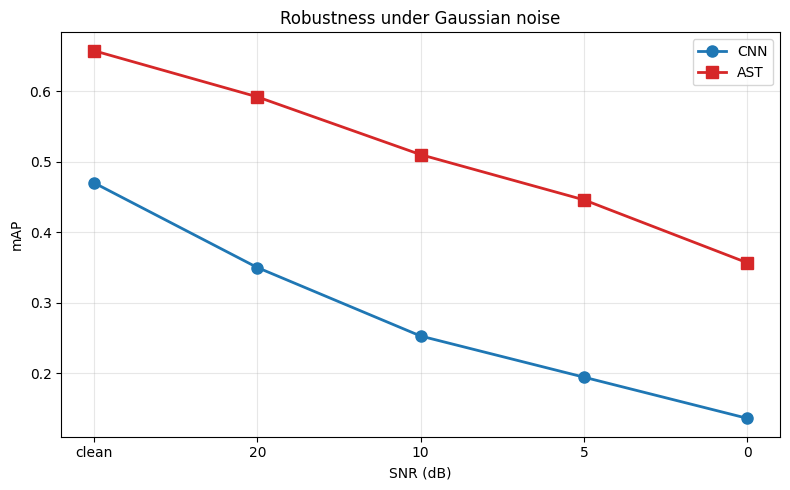

In [28]:
def plot_noise_curve(results_df, noise_type, ax, title):
    """Plot mAP vs SNR for both models under a given noise type."""
    snr_order = ["clean", 20, 10, 5, 0]
    for model_name, color, marker in [("CNN", "tab:blue", "o"),
                                       ("AST", "tab:red",  "s")]:
        subset = results_df[(results_df["model"] == model_name) &
                            ((results_df["noise_type"] == noise_type) |
                             (results_df["noise_type"] == "clean"))]
        subset = subset.drop_duplicates(subset=["snr_db"])
        subset["snr_sort"] = subset["snr_db"].map(
            {s: i for i, s in enumerate(snr_order)}
        )
        subset = subset.sort_values("snr_sort")
        ax.plot(range(len(subset)), subset["mAP"], marker=marker,
                color=color, label=model_name, linewidth=2, markersize=8)
    ax.set_xticks(range(len(snr_order)))
    ax.set_xticklabels([str(s) if s != "clean" else "clean" for s in snr_order])
    ax.set_xlabel("SNR (dB)")
    ax.set_ylabel("mAP")
    ax.set_title(title)
    ax.legend()
    ax.grid(alpha=0.3)

fig, ax = plt.subplots(figsize=(8, 5))
plot_noise_curve(results_df, "gaussian", ax, "Robustness under Gaussian noise")
plt.tight_layout()
plt.show()

## **Figure 2: mAP vs SNR (Pink noise)**

Same visualization under pink noise, closer to real environmental interference.

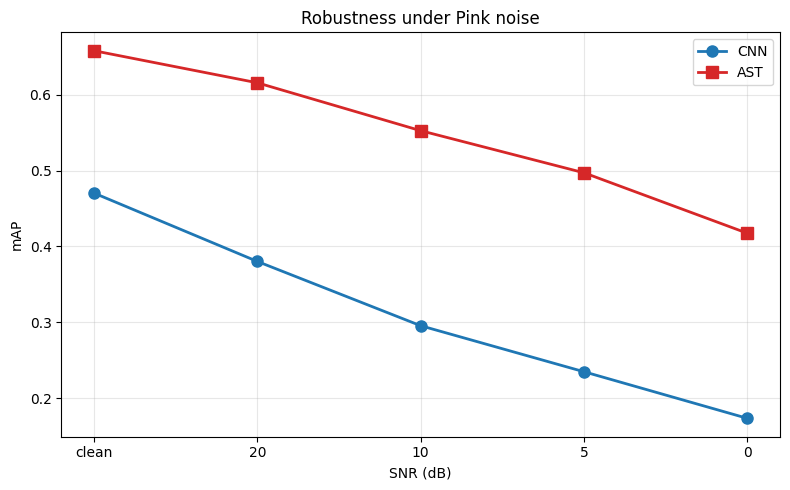

In [29]:
fig, ax = plt.subplots(figsize=(8, 5))
plot_noise_curve(results_df, "pink", ax, "Robustness under Pink noise")
plt.tight_layout()
plt.show()

## **Figure 3: Relative degradation**

Each model's mAP at each SNR level is expressed as a percentage of its own clean baseline. This normalizes for the fact that the two models start from different absolute performances. A flatter curve means higher relative robustness.

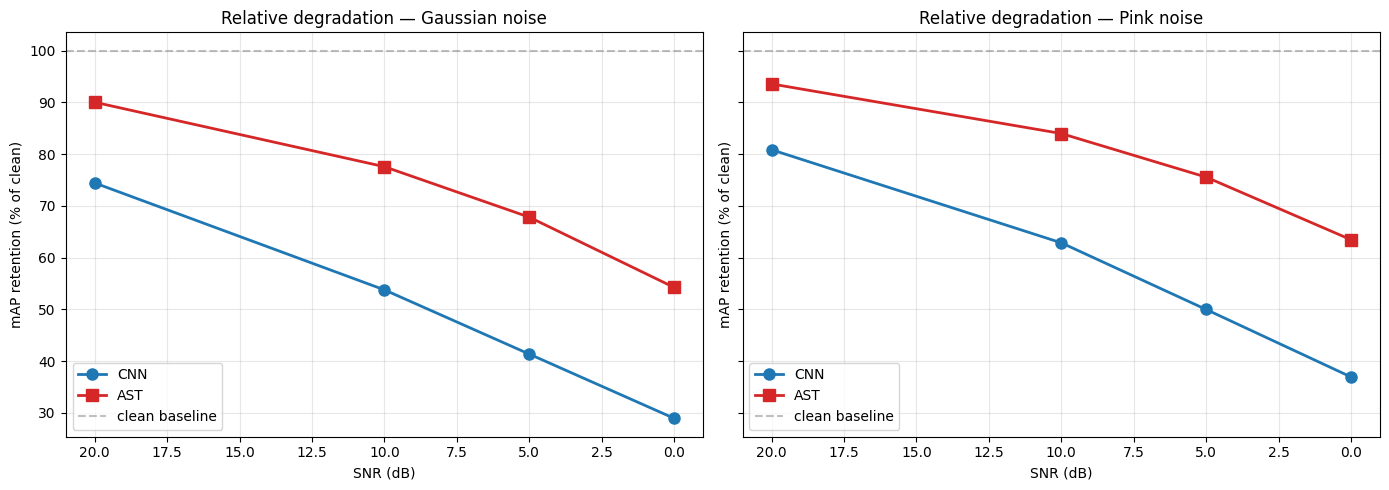

In [30]:
# Build a long-format dataframe with relative degradation
rel_rows = []
for model_name in ["CNN", "AST"]:
    clean_map = results_df[(results_df["model"] == model_name) &
                           (results_df["noise_type"] == "clean")]["mAP"].values[0]
    for noise_type in ["gaussian", "pink"]:
        for snr in [20, 10, 5, 0]:
            m = results_df[(results_df["model"] == model_name) &
                           (results_df["noise_type"] == noise_type) &
                           (results_df["snr_db"] == snr)]["mAP"].values[0]
            rel_rows.append({
                "model":      model_name,
                "noise_type": noise_type,
                "snr_db":     snr,
                "rel_mAP_%":  100 * m / clean_map,
            })

rel_df = pd.DataFrame(rel_rows)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, ntype in zip(axes, ["gaussian", "pink"]):
    subset = rel_df[rel_df["noise_type"] == ntype]
    for model_name, color, marker in [("CNN", "tab:blue", "o"),
                                       ("AST", "tab:red",  "s")]:
        ms = subset[subset["model"] == model_name].sort_values("snr_db", ascending=False)
        ax.plot(ms["snr_db"], ms["rel_mAP_%"], marker=marker, color=color,
                label=model_name, linewidth=2, markersize=8)
    ax.axhline(100, color="gray", linestyle="--", alpha=0.5, label="clean baseline")
    ax.set_xlabel("SNR (dB)")
    ax.set_ylabel("mAP retention (% of clean)")
    ax.set_title(f"Relative degradation — {ntype.capitalize()} noise")
    ax.legend()
    ax.grid(alpha=0.3)
    ax.invert_xaxis()   # higher SNR on the left

plt.tight_layout()
plt.show()

## **Figure 4: Gaussian vs Pink per model**

Directly compares the two noise types for each model. Answers the question: is a given model more sensitive to one noise type than to the other?

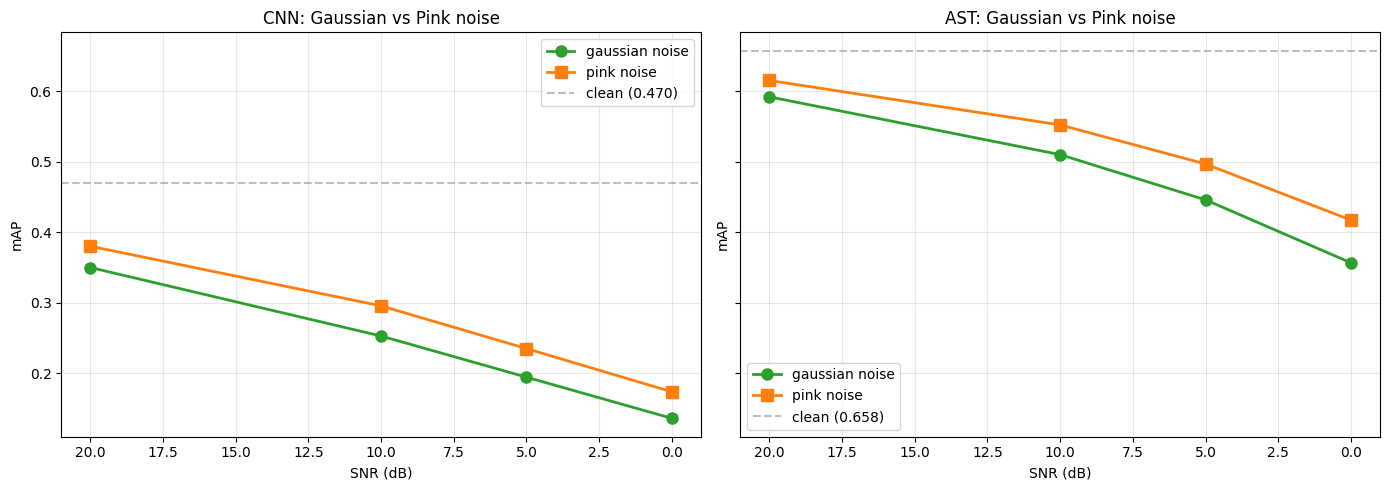

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
snr_order = [20, 10, 5, 0]

for ax, model_name in zip(axes, ["CNN", "AST"]):
    for ntype, color, marker in [("gaussian", "tab:green",  "o"),
                                  ("pink",     "tab:orange", "s")]:
        subset = results_df[(results_df["model"] == model_name) &
                            (results_df["noise_type"] == ntype)]
        subset = subset.sort_values("snr_db", ascending=False)
        ax.plot(subset["snr_db"], subset["mAP"], marker=marker,
                color=color, label=f"{ntype} noise", linewidth=2, markersize=8)
    clean_mAP = results_df[(results_df["model"] == model_name) &
                           (results_df["noise_type"] == "clean")]["mAP"].values[0]
    ax.axhline(clean_mAP, color="gray", linestyle="--", alpha=0.5,
               label=f"clean ({clean_mAP:.3f})")
    ax.set_xlabel("SNR (dB)")
    ax.set_ylabel("mAP")
    ax.set_title(f"{model_name}: Gaussian vs Pink noise")
    ax.legend()
    ax.grid(alpha=0.3)
    ax.invert_xaxis()

plt.tight_layout()
plt.show()

## **Figure 5: Heatmap summary**

Compact visualization of all three metrics (mAP, micro-F1, macro-F1) across the full 2 × 5 grid, for both models.

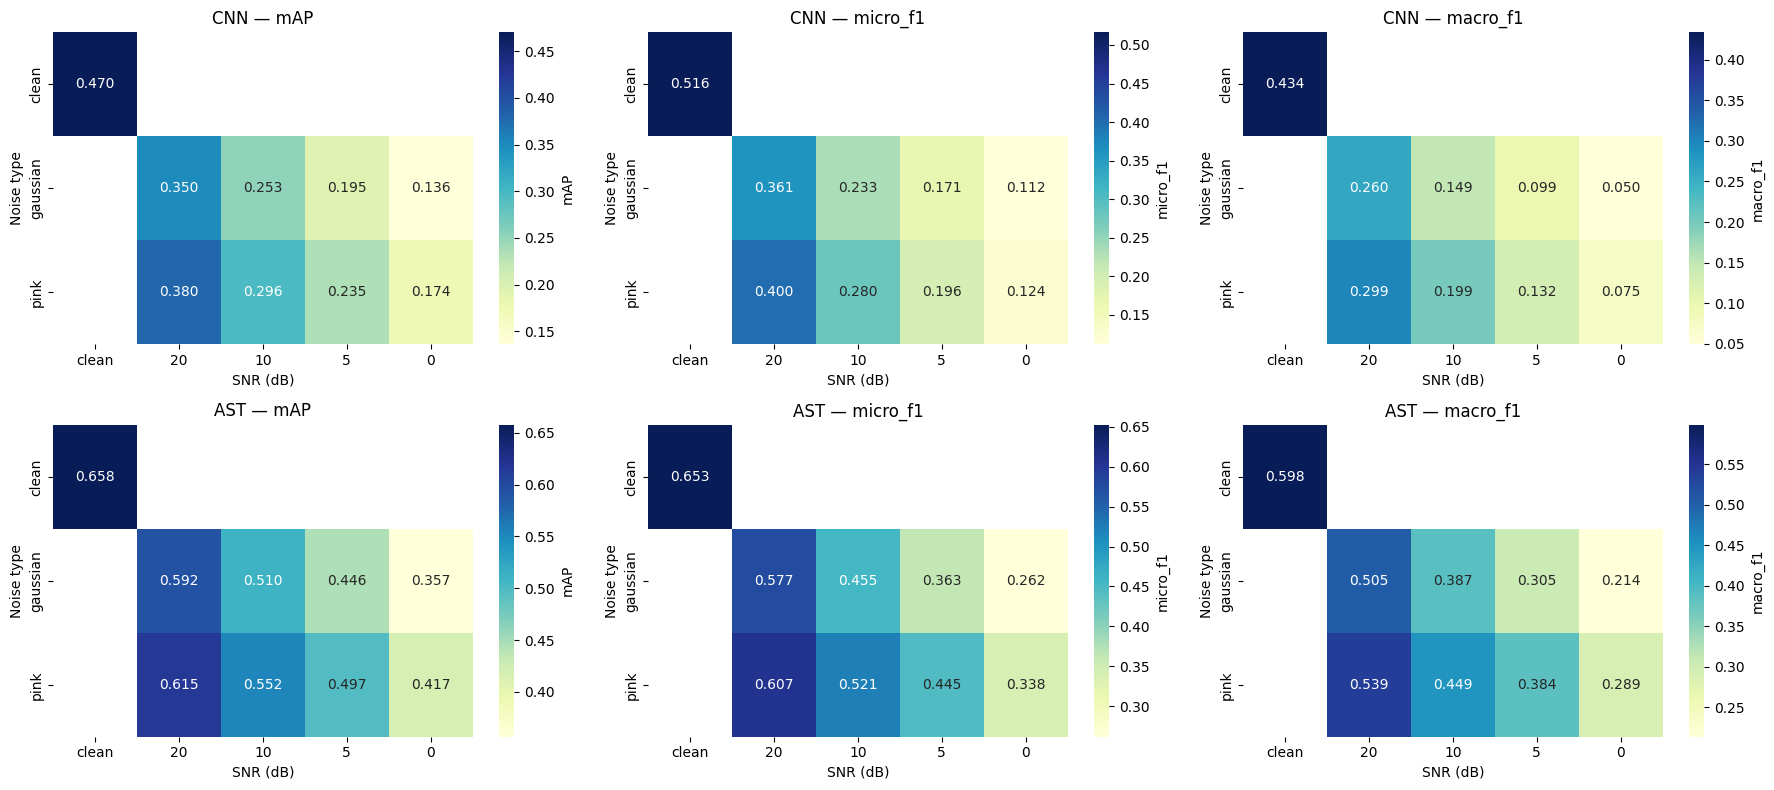

In [32]:
fig, axes = plt.subplots(2, 3, figsize=(18, 8))

for row_i, model_name in enumerate(["CNN", "AST"]):
    for col_i, metric in enumerate(["mAP", "micro_f1", "macro_f1"]):
        pivot = results_df[results_df["model"] == model_name].pivot_table(
            index="noise_type", columns="snr_db", values=metric
        )
        # Reorder columns: clean, 20, 10, 5, 0
        col_order = ["clean", 20, 10, 5, 0]
        col_order = [c for c in col_order if c in pivot.columns]
        pivot = pivot[col_order]
        sns.heatmap(pivot, annot=True, fmt=".3f", cmap="YlGnBu",
                    ax=axes[row_i, col_i],
                    cbar_kws={"label": metric})
        axes[row_i, col_i].set_title(f"{model_name} — {metric}")
        axes[row_i, col_i].set_xlabel("SNR (dB)")
        axes[row_i, col_i].set_ylabel("Noise type")

plt.tight_layout()
plt.show()

## **Discussion of Robustness Results**

### Absolute robustness

The AST outperforms the CNN at every noise level evaluated. The gap is largest in the clean condition (+0.19 mAP) and narrows slightly under heavy noise, but the AST remains clearly ahead even at 0 dB SNR — the most degraded condition tested. Notably, the AST at 0 dB Pink noise (mAP = 0.417) performs at a level comparable to the CNN in its *clean* condition (mAP = 0.470). This highlights that the AST's advantage is not simply a matter of starting from a higher baseline: it generalizes better to corrupted input.

### Relative robustness

Measured as the percentage of clean performance retained at each SNR:

| Condition | CNN | AST |
|---|---|---|
| 0 dB Gaussian | 29% | 54% |
| 0 dB Pink | 37% | 63% |

The CNN loses ~70% of its clean performance under the worst Gaussian condition, while the AST loses only ~46%. This confirms that the AST is not only more accurate but also structurally more robust: it degrades at a lower rate. This is a non-trivial architectural advantage distinct from raw performance.

### Gaussian vs Pink noise

Pink noise degrades both models less than Gaussian noise at every SNR level, but the AST benefits more from the frequency-dependent structure of pink noise than the CNN does. At 0 dB, the AST's mAP is 0.060 higher under Pink than Gaussian, while the CNN gains only 0.038. This suggests the AST exploits the uncontaminated high-frequency regions of pink noise more effectively, consistent with the hypothesis that its attention mechanism integrates information across the spectrum in ways a local convolutional receptive field cannot.

### Interpretation

Two factors likely underlie the AST's superior robustness. First, the AudioSet pretraining exposes the model to a wide distribution of realistic acoustic conditions, including naturally noisy clips, which builds an implicit prior for dealing with degraded input. Second, the global attention mechanism allows the AST to integrate evidence across the full 10-second clip, mitigating the impact of localized spectral damage that would hurt a CNN's local receptive field disproportionately.

SpecAugment during training contributed to both models but appears to have a compounding effect on the AST, likely because pretraining already provided a robustness floor that augmentation could build upon.

### Practical implications

If the models were to be deployed in real environments (mobile devices, outdoor recording, crowded spaces), the AST is the clear choice: at realistic noise levels (10 dB SNR, typical of moderate background), the AST maintains ~0.52 mAP (Gaussian) and ~0.55 mAP (Pink), while the CNN falls to 0.25 and 0.30 respectively. The practical gap is even more pronounced under noise than under clean conditions.

### Limitations of the study

The evaluation uses synthetic noise (Gaussian, Pink) added at the waveform level. Real-world noise has structural content (voices, specific environmental sounds) that is not captured by these stationary noise models. A future extension could evaluate robustness on mixtures with actual environmental recordings (e.g., MUSAN, DEMAND datasets), though this falls outside the scope of the present project.
